<a href="https://colab.research.google.com/github/Prithvi-kun/Facial-Emotion-Detection-using-CNN/blob/main/Facial%20Emotion%20Recongnition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Facial Emotion Recognition**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aadityasinghal/facial-expression-dataset")


Using Colab cache for faster access to the 'facial-expression-dataset' dataset.


In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, Flatten, MaxPooling2D


## Load the dataset

In [ ]:
TRAIN_DIR="/kaggle/input/facial-expression-dataset/train/train"
TEST_DIR="/kaggle/input/facial-expression-dataset/test/test"

In [ ]:
def load_dataset(directory):
    image_paths=[]
    labels=[]

    for label in os.listdir(directory):
        for filename in os.listdir(os.path.join(directory, label)):
            image_path=os.path.join(directory,label,filename)
            image_paths.append(image_path)
            labels.append(label)
        print(label, "Completed")
    return image_paths,labels

In [ ]:
train=pd.DataFrame()
train['image'],train['label']=load_dataset(TRAIN_DIR)
train=train.sample(frac=1).reset_index(drop=True)
train.head()

surprise Completed
fear Completed
angry Completed
neutral Completed
sad Completed
disgust Completed
happy Completed


,image,label
0,/kaggle/input/facial-expression-dataset/train/...,surprise
1,/kaggle/input/facial-expression-dataset/train/...,angry
2,/kaggle/input/facial-expression-dataset/train/...,fear
3,/kaggle/input/facial-expression-dataset/train/...,happy
4,/kaggle/input/facial-expression-dataset/train/...,surprise


In [ ]:
test=pd.DataFrame()
test['image'],test['label']=load_dataset(TEST_DIR)
test.head()

surprise Completed
fear Completed
angry Completed
neutral Completed
sad Completed
disgust Completed
happy Completed


,image,label
0,/kaggle/input/facial-expression-dataset/test/t...,surprise
1,/kaggle/input/facial-expression-dataset/test/t...,surprise
2,/kaggle/input/facial-expression-dataset/test/t...,surprise
3,/kaggle/input/facial-expression-dataset/test/t...,surprise
4,/kaggle/input/facial-expression-dataset/test/t...,surprise


## Exploratory data analysis

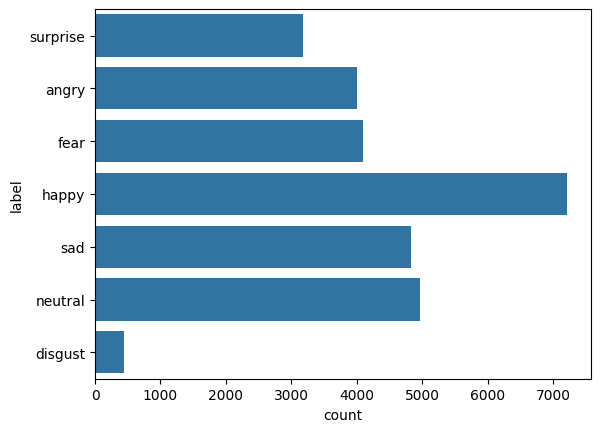

In [ ]:
sns.countplot(train['label']);

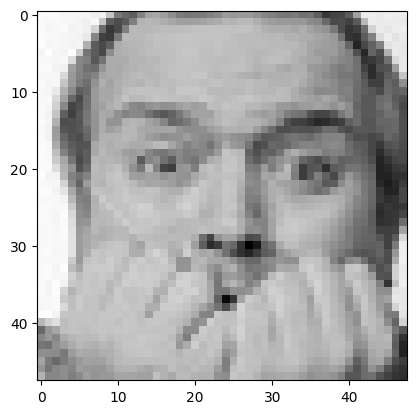

In [ ]:
from PIL import Image
img=Image.open(train['image'][0])
plt.imshow(img, cmap='grey');

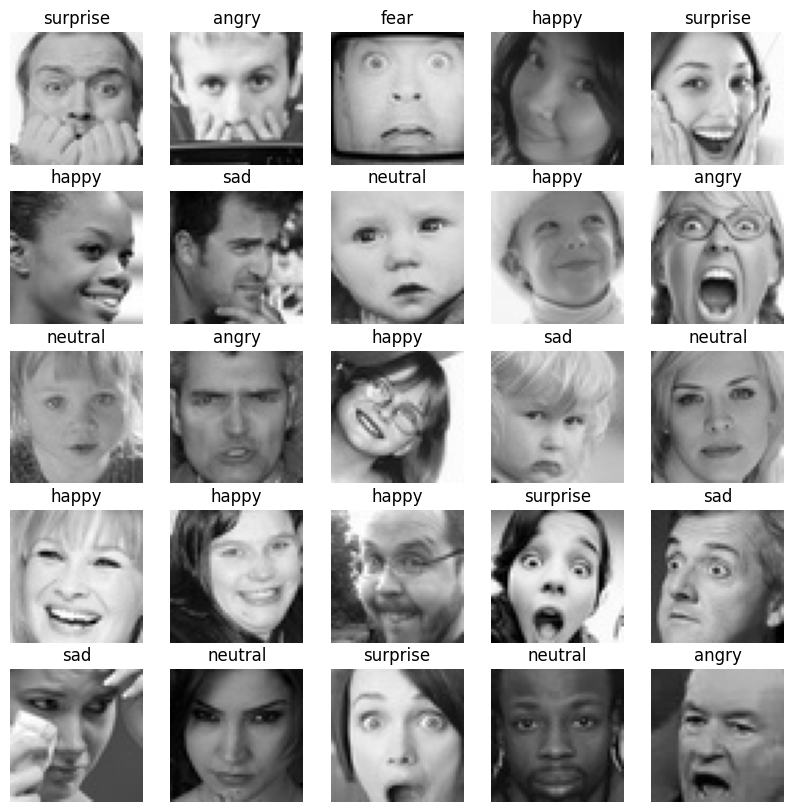

In [ ]:
plt.figure(figsize=(10,10))
files=train.iloc[0:25]

for index,file,label in files.itertuples():
    plt.subplot(5,5,index+1)
    img=load_img(file)
    img=np.array(img)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')


## Feature extraction

In [ ]:
def extract_features(images):
    features=[]
    for image in tqdm(images):
        img=load_img(image, color_mode='grayscale')
        img=np.array(img)
        features.append(img)
    features=np.array(features)
    features=features.reshape(len(features), 48, 48, 1)
    return features

In [ ]:
train_features=extract_features(train['image'])

  0%|          | 0/28709 [00:00<?, ?it/s]

In [ ]:
test_features=extract_features(test['image'])

  0%|          | 0/7178 [00:00<?, ?it/s]

In [ ]:
#normalise the image

x_train=train_features/255.0
x_test=test_features/255.0


In [ ]:
#convert label to integer

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit_transform(train['label'])
y_train=le.transform(train['label'])
y_test=le.transform(test['label'])

In [ ]:
y_train=to_categorical(y_train, num_classes=7)
y_test=to_categorical(y_test, num_classes=7)

In [ ]:
y_train[0]

array([0., 0., 0., 0., 0., 0., 1.])

In [ ]:
#config

input_shape=(48,48,1)
output_classes=7

## Model creation

In [ ]:
model=Sequential()
#convolutional layers
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(128,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
#fully connected layers
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
#output layer
model.add(Dense(output_classes,activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the EarlyStopping callback
# Monitor validation loss and stop if it doesn't improve for 10 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
#train the model
history=model.fit(x=x_train,y=y_train, batch_size=128, epochs=100, validation_data=(x_test,y_test), callbacks=[early_stopping])

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.2238 - loss: 1.8752 - val_accuracy: 0.2471 - val_loss: 1.8364
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2519 - loss: 1.8141 - val_accuracy: 0.3345 - val_loss: 1.7184
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3127 - loss: 1.6959 - val_accuracy: 0.4331 - val_loss: 1.5063
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3913 - loss: 1.5587 - val_accuracy: 0.4627 - val_loss: 1.4196
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4273 - loss: 1.4946 - val_accuracy: 0.4826 - val_loss: 1.3528
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4534 - loss: 1.4269 - val_accuracy: 0.4951 - val_loss: 1.3285
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4620 - loss: 1.4044 - val_accuracy: 0.5022 - val_loss: 1.2936
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4790 - loss: 1.3659 -

## Plot the results

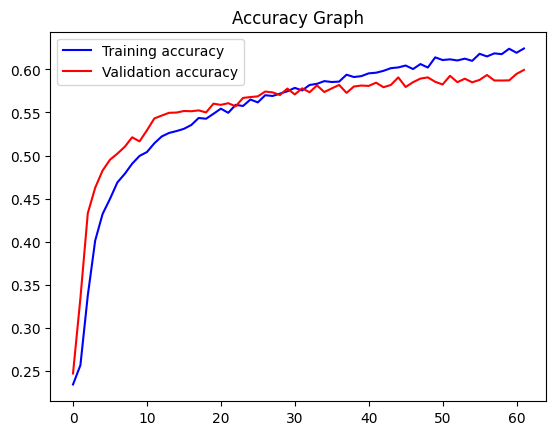

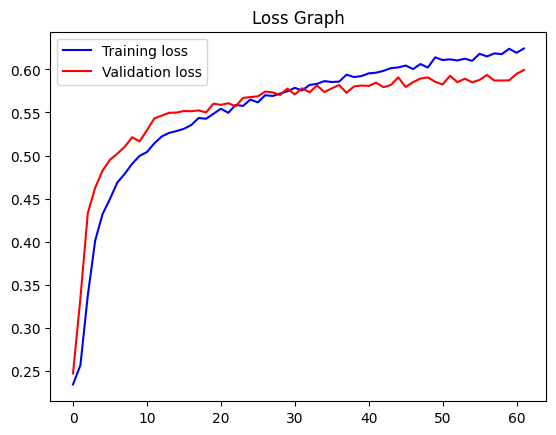

<Figure size 640x480 with 0 Axes>

In [ ]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
epochs=range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(len(acc))

plt.plot(epochs, acc, 'b', label='Training loss')
plt.plot(epochs, val_acc, 'r', label='Validation loss')
plt.title('Loss Graph')
plt.legend()
plt.figure()

plt.show()

## Test with image data

Original Output:  neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
Predicted Output:  neutral


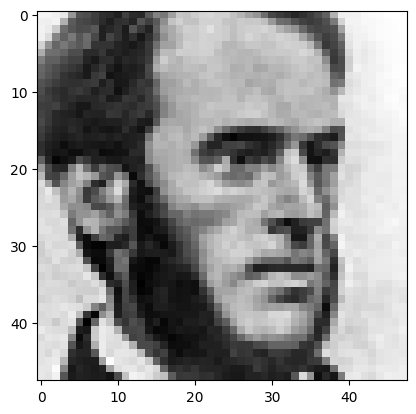

In [ ]:
image_index=random.randint(0,len(test))
print("Original Output: ",test['label'][image_index])
pred=model.predict(x_test[image_index].reshape(1,48,48,1))
prediction_label=le.inverse_transform([pred.argmax()])[0]
print("Predicted Output: ", prediction_label)
plt.imshow(x_test[image_index].reshape(48,48), cmap='gray')

In [ ]:
# Save the trained model
model.save('facial_emotion_model.keras')
print("Model saved successfully!")

Model saved successfully!


## About

### 1. Data Loading and Exploration

- **Dataset:** The dataset used is the "Facial Expression Dataset" from Kaggle. It contains images of faces labeled with different emotions (angry, disgust, fear, happy, neutral, sad, surprise).
- **Loading:** The `kagglehub` library is used to download the dataset. The `load_dataset` function reads the image paths and their corresponding labels from the train and test directories.
- **DataFrames:** The loaded data is stored in pandas DataFrames for easy manipulation and analysis.
- **Exploration:** We visualize the distribution of emotions in the training set using a countplot and display sample images to understand the data.



### 2. Feature Extraction and Preprocessing

- **Feature Extraction:** The `extract_features` function reads the images, converts them to grayscale, and stores them as NumPy arrays. The images are resized to 48x48 pixels.
- **Normalization:** The pixel values are normalized by dividing by 255.0 to scale them between 0 and 1. This helps in faster and better convergence of the model.
- **Label Encoding:** The categorical emotion labels (strings) are converted into numerical representations using `LabelEncoder`.
- **One-Hot Encoding:** The numerical labels are then converted into one-hot encoded vectors. This is required for the categorical crossentropy loss function used in the model.



### 3. Model Creation and Training

- **Model Architecture:** A Sequential CNN model is built with multiple convolutional layers, max-pooling layers, and dropout layers.
    - **Convolutional Layers:** Extract features from the images by applying filters.
    - **Max-Pooling Layers:** Reduce the spatial dimensions of the output from convolutional layers, helping to reduce the number of parameters and computation.
    - **Dropout Layers:** Randomly set a fraction of input units to 0 at each update during training, which helps prevent overfitting.
- **Flatten Layer:** Flattens the output from the convolutional layers into a 1D vector to be fed into the fully connected layers.
- **Dense Layers:** Fully connected layers that perform the classification.
- **Output Layer:** A dense layer with a softmax activation function that outputs the probabilities for each emotion class.
- **Compilation:** The model is compiled with the Adam optimizer, categorical crossentropy loss function, and accuracy as the evaluation metric.
- **Early Stopping:** An EarlyStopping callback is used to stop training when the validation loss stops improving for a certain number of epochs, preventing overfitting.
- **Training:** The model is trained using the `fit` method, providing the training data, batch size, number of epochs, and validation data.



### 4. Model Evaluation and Testing

- **Plotting Results:** The training and validation accuracy and loss are plotted over epochs to visualize the model's performance and check for overfitting.
- **Testing with Image Data:** A random image from the test set is selected, and the model predicts its emotion. The predicted label is compared with the original label, and the image is displayed.
- **Saving the Model:** The trained model is saved for future use.

